# Project 4: Using Deep Agents with LangChain and LangGraph



In [5]:
# Imports and environment first

import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools import GoogleSerperRun
from langchain_community.utilities import GoogleSerperAPIWrapper
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend

load_dotenv(override=True)

True

## A web search tool



In [6]:
search = GoogleSerperRun(api_wrapper=GoogleSerperAPIWrapper())

## A research agent that plans, searches and writes



We point the agent's filesystem at a real `sandbox` folder, so anything it writes appears as a file on disk that we can open afterwards. The agent sees its filesystem at `/`, so when it reports writing to `/charging.md`, that appears as `charging.md` inside our sandbox folder.

It will write itself a todo list, search the web a few times and save a briefing to a file.

In [7]:
sandbox = os.path.abspath("sandbox")
os.makedirs(sandbox, exist_ok=True)

model = ChatOpenAI(model="gpt-5.4-mini")

researcher = create_deep_agent(
    model=model,
    tools=[search],
    system_prompt=(
        "You are a research analyst. Plan your work with your todo tool, "
        "research with the search tool, and write your findings as a tidy markdown briefing to a file."
    ),
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

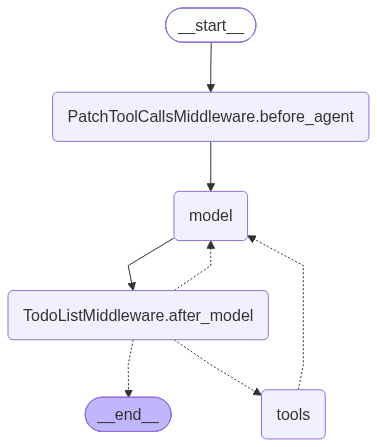

In [ ]:
researcher

In [10]:
brief = """
Our company is planning to move its sales fleet to JR electrostatic chuck.
Research the current landscape in the US: find out roughly how many major vendors there are.
Write a one page markdown briefing, with a heading and a short section for each, to the file charging.md.
"""

result = researcher.invoke({"messages": [{"role": "user", "content": brief}]})
print(result["messages"][-1].content)

HTTPError: 403 Client Error: Forbidden for url: https://google.serper.dev/search?q=JR+electrostatic+chuck+vendor+US+market+major+manufacturers+electrostatic+chuck&gl=us&hl=en&num=10

Let us see how it worked. First, the tools it chose to call, which reveal the planning and the file writing. Then we'll go and look in the sandbox folder.

In [11]:
tools_used = [tc["name"] for m in result["messages"] for tc in (getattr(m, "tool_calls", []) or [])]
print("Tools the agent called, in order:")
print(tools_used)

NameError: name 'result' is not defined

## Sub-agents: handing off focused work

A sub-agent is a helper the main agent can delegate to through its `task` tool. The helper runs with its own fresh context, does one job, and reports back a tidy result. This keeps the main agent's attention clear when a task has several independent pieces.

The charging briefing answered whether the fleet switch is feasible. The next question the company will ask is which car to buy, and that splits naturally into independent pieces: each candidate vehicle can be researched on its own. So we define a vehicle researcher sub-agent, and ask the main agent to compare two contenders for the fleet by delegating the research on each.

In [12]:
research_ev_instructions = """
You research one electrostatic chuck using the search tool and return three concise facts
that a chuck buyer would care about, such as price and temperature range.
"""

overall_instructions = """
You write comparison briefings for a company choosing electrostatic chuck.
For each chuck, delegate the research to your vehicle-researcher sub-agent,
then write a markdown comparison to a file, ending with a clear recommendation.
"""


research_subagent = {
    "name": "vehicle-researcher",
    "description": "Researches a single chuck and returns a short list of facts about it.",
    "system_prompt": research_ev_instructions,
}

lead = create_deep_agent(
    model=model,
    tools=[search],
    system_prompt=overall_instructions,
    subagents=[research_subagent],
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
)

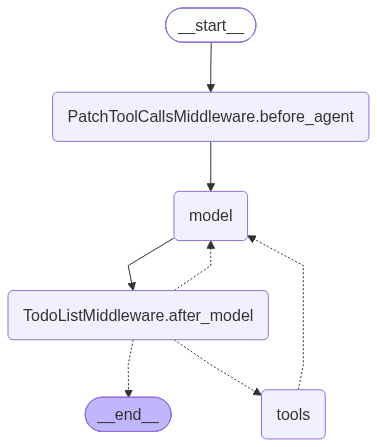

In [13]:
lead

In [14]:
mission = """
Compare a Lam research chuck vs an AMAT chuck as candidates.
Research each chuck, then write a 50 word markdown comparison with a recommendation to chuck.md.
"""

result = lead.invoke({"messages": [{"role": "user", "content": mission}]})

HTTPError: 403 Client Error: Forbidden for url: https://google.serper.dev/search?q=Lam+Research+electrostatic+chuck+product+specifications+model+temperature+range+RF+clamping+wafer+electrostatic+chuck&gl=us&hl=en&num=10

In [15]:
tools_used = [tc["name"] for m in result["messages"] for tc in (getattr(m, "tool_calls", []) or [])]
print("Tools the lead agent called:", tools_used)

NameError: name 'result' is not defined

### Now go and look at `fleet.md` in the Sandbox folder